## Condition Configuration

This notebook prepares reusable data artifacts for the selected condition.

- `CONDITION`: condition name under `data/ai-proposals/` and `data/ai-proposals/rephrased/`.
- `BASE_CONDITION`: raw proposal/review condition name before adding the `rephrased/` prefix.


In [22]:
CONDITION = 'minimal'
BASE_CONDITION = 'minimal'


# Prepare Data for Analysis

This notebook creates reusable prepared artifacts for the rephrased/minimal analyses. It deliberately stops before analysis-specific metrics such as diversity, novelty scores, outlier flags, and metric_score_df.

Outputs:
- prepared proposal records: original + rephrased text, no analysis-derived metrics
- NCEMS all-reviews table and novelty all-reviews table
- full rephrased proposal embeddings
- abstract-only rephrased proposal embeddings for PubMed/literature comparisons
- literature abstract embeddings
- review embeddings for NCEMS and novelty reviews


## 1. Setup

In [23]:
import json
import os
import pickle
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel


def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate.resolve()
    raise RuntimeError('Could not find project root containing src/ and data/.')


PROJECT_ROOT = find_project_root()
condition = f'rephrased/{CONDITION}'
base_condition = BASE_CONDITION

RESULTS_DIR = PROJECT_ROOT / 'results'
TABLES_DIR = RESULTS_DIR / 'tables' / condition
PREPARED_DIR = PROJECT_ROOT / 'data' / 'prepared' / condition
PREPARED_DIR.mkdir(parents=True, exist_ok=True)

AI_ORIGINAL_DIR = PROJECT_ROOT / 'data' / 'ai-proposals' / base_condition
AI_REPHRASED_DIR = PROJECT_ROOT / 'data' / 'ai-proposals' / condition
HUMAN_ORIGINAL_DIR = PROJECT_ROOT / 'data' / 'human-proposals'
HUMAN_REPHRASED_DIR = PROJECT_ROOT / 'data' / 'human-proposals' / 'rephrased'

NCEMS_AI_REVIEWS_DIR = PROJECT_ROOT / 'data' / 'reviews' / 'ai_reviews' / base_condition / 'ncems_criteria' / 'rephrased'
NOVELTY_AI_REVIEWS_DIR = PROJECT_ROOT / 'data' / 'reviews' / 'ai_reviews' / base_condition / 'novelty'
HUMAN_REVIEWS_DIR = PROJECT_ROOT / 'data' / 'reviews' / 'human_reviews' / 'rephrased'
HUMAN_REVIEWS_ORIGINAL_DIR = PROJECT_ROOT / 'data' / 'reviews' / 'human_reviews'
NCEMS_AI_REVIEWS_ORIGINAL_DIR = PROJECT_ROOT / 'data' / 'reviews' / 'ai_reviews' / base_condition / 'ncems_criteria'
HUMAN_PROPOSALS_Y1_PATH = PROJECT_ROOT / 'data' / 'human-proposals' / 'human-proposals-y1.json'
HUMAN_PROPOSALS_Y2_PATH = PROJECT_ROOT / 'data' / 'human-proposals' / 'human-proposals-y2.json'
LITERATURE_PATH = PROJECT_ROOT / 'data' / 'literature' / 'relevant-corpus-from-pubmed.json'

ALL_PROPOSALS_PATH = TABLES_DIR / 'all_proposals.json'
PREPARED_ALL_PROPOSALS_PATH = PREPARED_DIR / 'all_proposals.json'
PREPARED_ALL_PROPOSALS_CSV = PREPARED_DIR / 'all_proposals.csv'
NCEMS_ALL_REVIEWS_PATH = PREPARED_DIR / 'ncems_criteria_all_reviews.csv'
NOVELTY_ALL_REVIEWS_PATH = PREPARED_DIR / 'novelty_all_reviews.csv'
REVIEW_SCORES_WIDE_PATH = PREPARED_DIR / 'review_scores_wide.csv'
HUMAN_Y2_SCORES_WIDE_PATH = PREPARED_DIR / 'human_y2_scores_wide.csv'
PREPARED_LITERATURE_CORPUS_PATH = PREPARED_DIR / 'literature_corpus_prepared.json'

EMBEDDINGS_DIR = PROJECT_ROOT / 'data' / 'embeddings'
PROPOSAL_FULL_EMBEDDINGS_FILE = EMBEDDINGS_DIR / condition / 'proposal_embeddings_human_ai_rephrased.pkl'
PROPOSAL_ABSTRACT_EMBEDDINGS_FILE = EMBEDDINGS_DIR / condition / 'proposal_embeddings_section1_only.pkl'
LITERATURE_EMBEDDINGS_FILE = EMBEDDINGS_DIR / 'literature' / 'relevant_literature_embeddings.pkl'
NCEMS_REVIEW_EMBEDDINGS_FILE = EMBEDDINGS_DIR / 'reviews' / base_condition / 'ncems_criteria' / f'review_embeddings_{base_condition}.pkl'
NCEMS_REVIEW_STRENGTHS_EMBEDDINGS_FILE = EMBEDDINGS_DIR / 'reviews' / base_condition / 'ncems_criteria' / f'review_strengths_embeddings_{base_condition}.pkl'
NCEMS_REVIEW_WEAKNESS_EMBEDDINGS_FILE  = EMBEDDINGS_DIR / 'reviews' / base_condition / 'ncems_criteria' / f'review_weakness_embeddings_{base_condition}.pkl'
NOVELTY_REVIEW_EMBEDDINGS_FILE = EMBEDDINGS_DIR / 'reviews' / base_condition / 'novelty' / f'review_embeddings_{base_condition}.pkl'

for p in [PROPOSAL_FULL_EMBEDDINGS_FILE, PROPOSAL_ABSTRACT_EMBEDDINGS_FILE, LITERATURE_EMBEDDINGS_FILE, NCEMS_REVIEW_EMBEDDINGS_FILE, NOVELTY_REVIEW_EMBEDDINGS_FILE]:
    p.parent.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Prepared tables: {PREPARED_DIR}')

Project root: /Users/eveyhuang/Documents/NICO/human-AI-proposal
Prepared tables: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal


## 2. Shared Helpers

In [24]:
SECTION_HEADERS = [
    'SCIENTIFIC BACKGROUND AND RESEARCH QUESTION',
    'METHODOLOGY AND ANALYTICAL APPROACH',
    'DATA SOURCES AND SYNTHESIS PLAN',
    'FEASIBILITY AND TIMELINE',
    'OPEN SCIENCE AND TEAM COMPOSITION',
]


def normalize_title(title):
    if pd.isna(title):
        return ''
    title = str(title).strip().lower()
    title = re.sub(r'\s+', ' ', title)
    title = re.sub(r'[^a-z0-9 ]', '', title)
    return title


def strip_section_headers(text):
    text = '' if pd.isna(text) else str(text)
    for header in SECTION_HEADERS:
        text = re.sub(rf'^\s*{re.escape(header)}\s*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    return re.sub(r'\n{3,}', '\n\n', text).strip()


def first_existing(paths, description):
    paths = sorted(paths)
    if not paths:
        raise FileNotFoundError(f'No {description} found')
    return paths[-1]


def safe_text(value):
    return '' if pd.isna(value) else str(value)


def proposal_abstract_text(row):
    candidates = [
        row.get('abstract'),
        row.get('section1'),
        row.get('scientific_background_and_research_question'),
        row.get('main_idea'),
    ]
    for value in candidates:
        text = safe_text(value).strip()
        if text:
            return strip_section_headers(text)
    full = strip_section_headers(row.get('standardized_text', ''))
    return full.split('\n\n', 1)[0].strip() if full else ''

## 3. Build Prepared Proposal Records

In [25]:
ai_original_path = first_existing(AI_ORIGINAL_DIR.glob('ai_proposals_minimal_complete_*.csv'), f'original AI proposal CSV in {AI_ORIGINAL_DIR}')
ai_rephrased_path = first_existing(AI_REPHRASED_DIR.glob('ai_proposals_minimal_rephrased_*.csv'), f'rephrased AI proposal CSV in {AI_REPHRASED_DIR}')

ai_original = pd.read_csv(ai_original_path)
ai_rephrased = pd.read_csv(ai_rephrased_path)
ai_rephrased['_key'] = ai_rephrased['title'].map(normalize_title)
ai_rephrased_lut = {r['_key']: r for _, r in ai_rephrased.iterrows()}

AI_ORIGINAL_SECTIONS = [
    'abstract', 'background_and_significance', 'research_questions_and_hypotheses',
    'methods_and_approach', 'expected_outcomes_and_impact', 'budget_and_resources',
]

records = []
for _, row in ai_original.iterrows():
    key = normalize_title(row.get('title', ''))
    rep = ai_rephrased_lut.get(key, {})
    standardized_text = safe_text(rep.get('standardized_text', ''))
    abstract_text = proposal_abstract_text(rep)
    records.append({
        'title': row.get('title'),
        'title_norm': key,
        'group': row.get('model', 'AI'),
        'is_ai': True,
        'model': row.get('model'),
        'cohort': None,
        'source_file': ai_rephrased_path.name,
        'original': {s: row.get(s) for s in AI_ORIGINAL_SECTIONS},
        'rephrased': {
            'standardized_text': standardized_text,
            'full_text': strip_section_headers(standardized_text),
            'abstract_text': abstract_text,
            'main_idea': rep.get('main_idea'),
        },
        'metrics': {},
    })

for cohort in ['y1', 'y2']:
    original_path = HUMAN_ORIGINAL_DIR / f'human-proposals-{cohort}.json'
    rephrased_path = first_existing(HUMAN_REPHRASED_DIR.glob(f'human_proposals_rephrased_{cohort}_*.json'), f'rephrased human {cohort} proposal JSON in {HUMAN_REPHRASED_DIR}')

    with open(original_path) as f:
        original_payload = json.load(f)
    with open(rephrased_path) as f:
        rephrased_payload = json.load(f)

    rep_lut = {}
    for prop in rephrased_payload.get('proposals', rephrased_payload if isinstance(rephrased_payload, list) else []):
        title = prop.get('proposal_title', prop.get('title', ''))
        rep_lut[normalize_title(title)] = prop

    for prop in original_payload.get('proposals', original_payload if isinstance(original_payload, list) else []):
        title = prop.get('proposal_title', prop.get('title', ''))
        key = normalize_title(title)
        rep = rep_lut.get(key, {})
        standardized_text = safe_text(rep.get('standardized_text', ''))
        abstract_text = proposal_abstract_text(rep)
        records.append({
            'title': title,
            'title_norm': key,
            'group': 'Human',
            'is_ai': False,
            'model': None,
            'cohort': cohort,
            'source_file': rephrased_path.name,
            'original': {
                'abstract': prop.get('abstract'),
                'full_draft': prop.get('full_draft'),
            },
            'rephrased': {
                'standardized_text': standardized_text,
                'full_text': strip_section_headers(standardized_text),
                'abstract_text': abstract_text,
                'main_idea': rep.get('main_idea'),
            },
            'metrics': {},
        })

proposal_df = pd.DataFrame([{
    'title': r['title'],
    'title_norm': r['title_norm'],
    'group': r['group'],
    'is_ai': r['is_ai'],
    'model': r['model'],
    'cohort': r['cohort'],
    'source_file': r['source_file'],
    'standardized_text': r['rephrased']['standardized_text'],
    'full_text': r['rephrased']['full_text'],
    'abstract_text': r['rephrased']['abstract_text'],
    'main_idea': r['rephrased']['main_idea'],
} for r in records])

if proposal_df['title_norm'].duplicated().any():
    dupes = proposal_df.loc[proposal_df['title_norm'].duplicated(keep=False), ['title', 'group', 'cohort']]
    print('Warning: duplicated normalized titles:')
    display(dupes)

with open(PREPARED_ALL_PROPOSALS_PATH, 'w') as f:
    json.dump(records, f, indent=2, default=str)
with open(ALL_PROPOSALS_PATH, 'w') as f:
    json.dump(records, f, indent=2, default=str)
proposal_df.to_csv(PREPARED_ALL_PROPOSALS_CSV, index=False)

print(f'Saved prepared proposals: {PREPARED_ALL_PROPOSALS_PATH}')
print(f'Saved analysis-compatible proposals: {ALL_PROPOSALS_PATH}')
print(f'Saved flat proposal table: {PREPARED_ALL_PROPOSALS_CSV}')
print(proposal_df.groupby(['group', 'is_ai']).size())

Saved prepared proposals: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.json
Saved analysis-compatible proposals: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/all_proposals.json
Saved flat proposal table: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.csv
group                 is_ai
Human                 False    23
claude-opus-4-5       True     23
gemini-3-pro-preview  True     23
gpt-5.2               True     23
dtype: int64


## 4. Build Prepared Review Tables

In [26]:
NCEMS_CRITERIA_ORDER = [
    'Relevance_to_Emergent_Phenomena',
    'Novelty_and_Significance',
    'Rigor_of_Approach',
    'Scope_and_Timeline',
    'Synthesis_Focus',
    'Data_Identification',
    'Open_Science_Commitment',
]

NCEMS_CRITERION_MAP = {
    'Relevance to Emergent Phenomena': 'Relevance_to_Emergent_Phenomena',
    'Novelty & Significance': 'Novelty_and_Significance',
    'Rigor of Approach': 'Rigor_of_Approach',
    'Scope & Timeline': 'Scope_and_Timeline',
    'Synthesis Focus': 'Synthesis_Focus',
    'Data Identification': 'Data_Identification',
    'Open Science Commitment': 'Open_Science_Commitment',
}

HUMAN_NCEMS_COL_MAP = {
    'scientific_merit_and_innovation_score': ['Relevance_to_Emergent_Phenomena', 'Novelty_and_Significance', 'Rigor_of_Approach'],
    'feasibility_score': ['Scope_and_Timeline'],
    'data_sources_and_limitations_score': ['Synthesis_Focus', 'Data_Identification'],
    'open_science_compliance_score': ['Open_Science_Commitment'],
}

NOVELTY_CRITERIA_ORDER = [
    'new_question_topic_or_framing',
    'new_theory_concept_method_dataset_or_design',
    'unusual_combination_of_existing_ideas',
    'beyond_state_of_the_art',
    'credible_high_risk_high_gain',
    'unique_knowledge_generation',
]


def extract_human_proposal_rank_status(path, cohort_label):
    with open(path) as f:
        payload = json.load(f)
    rows = payload.get('human_proposals') or payload.get('proposals') or payload
    if not isinstance(rows, list):
        rows = []

    records = []
    for r in rows:
        title = r.get('proposal_title')
        status = safe_text(r.get('proposal_status')).strip()
        records.append({
            'cohort': cohort_label,
            'proposal_id': safe_text(r.get('proposal_id')).strip(),
            'title': title,
            'title_norm': normalize_title(title),
            'ranking': pd.to_numeric(r.get('ranking'), errors='coerce'),
            'proposal_status': status,
            'funding': 1 if status.lower() == 'accepted' else 0,
        })

    out = pd.DataFrame(records)
    if len(out):
        out['lookup_key'] = out['cohort'].astype(str) + '::' + out['proposal_id'].astype(str)
    return out


def load_human_rank_status_lookup():
    y1 = extract_human_proposal_rank_status(HUMAN_PROPOSALS_Y1_PATH, 'y1')
    y2 = extract_human_proposal_rank_status(HUMAN_PROPOSALS_Y2_PATH, 'y2')
    merged = pd.concat([y1, y2], ignore_index=True)
    by_key = merged.drop_duplicates(subset=['lookup_key'], keep='first')
    by_title = merged.drop_duplicates(subset=['cohort', 'title_norm'], keep='first')
    return by_key, by_title


def parse_ai_ncems_review_row(r):
    ev = (r.get('evaluations') or {}).get('evaluation')
    if not isinstance(ev, dict):
        return None

    criteria = {k: np.nan for k in NCEMS_CRITERIA_ORDER}
    justifications = []
    for category in ev.get('criteria_scores', []) or []:
        for sc in category.get('subcriteria', []) or []:
            c_name = NCEMS_CRITERION_MAP.get(sc.get('criterion'))
            if c_name is not None:
                criteria[c_name] = sc.get('score', np.nan)
            j = sc.get('justification')
            if isinstance(j, str) and j.strip():
                justifications.append(j.strip())

    overall = ev.get('overall_rating') or {}
    overall_summary = safe_text(overall.get('narrative_summary')).strip()
    overall_score = overall.get('final_numeric_score', np.nan)
    fallback_text = '\n\n'.join(justifications + ([overall_summary] if overall_summary else []))

    proposal_id = safe_text(ev.get('proposal_id')).strip() or safe_text(r.get('proposal_id')).strip()
    title = r.get('title')

    return {
        'proposal_id': proposal_id,
        'title': title,
        'title_norm': normalize_title(title),
        'author': r.get('author'),
        'evaluator': r.get('evaluator'),
        'overall_score': overall_score,
        'original_review_summary': overall_summary,
        'original_review_text': fallback_text,
        'original_raw_response': safe_text(r.get('raw_response')).strip(),
        **criteria,
    }


def build_ncems_ai_reviews():
    rephrased_path = first_existing(
        NCEMS_AI_REVIEWS_DIR.glob('ncems_reviews_rephrased*.json'),
        f'rephrased NCEMS AI reviews in {NCEMS_AI_REVIEWS_DIR}',
    )
    original_path = first_existing(
        NCEMS_AI_REVIEWS_ORIGINAL_DIR.glob('ncems_reviews_*.json'),
        f'original NCEMS AI reviews in {NCEMS_AI_REVIEWS_ORIGINAL_DIR}',
    )

    with open(rephrased_path) as f:
        rephrased_payload = json.load(f)
    with open(original_path) as f:
        original_payload = json.load(f)

    rephrased_rows = []
    for r in rephrased_payload.get('reviews', []):
        parsed = parse_ai_ncems_review_row(r)
        if parsed is None:
            continue
        parsed.update({
            'rephrased_review': safe_text(r.get('rephrased_review') or r.get('rephrased_reviews')).strip(),
            'strengths': safe_text(r.get('strengths')).strip(),
            'weakness': safe_text(r.get('weakness')).strip(),
        })
        rephrased_rows.append(parsed)

    original_rows = []
    for r in original_payload.get('reviews', []):
        parsed = parse_ai_ncems_review_row(r)
        if parsed is None:
            continue
        original_rows.append(parsed)

    rep_df = pd.DataFrame(rephrased_rows)
    orig_df = pd.DataFrame(original_rows)

    join_keys = ['title_norm', 'author', 'evaluator', 'proposal_id']
    if len(rep_df):
        rep_df['review_occurrence'] = rep_df.groupby(join_keys).cumcount()
    if len(orig_df):
        orig_df['review_occurrence'] = orig_df.groupby(join_keys).cumcount()

    merged = rep_df.merge(
        orig_df[join_keys + ['review_occurrence', 'original_review_summary', 'original_review_text', 'original_raw_response']],
        on=join_keys + ['review_occurrence'],
        how='left',
        suffixes=('', '_orig'),
    )

    merged['review_text'] = merged['rephrased_review'].where(merged['rephrased_review'].astype(str).str.strip() != '', merged['original_review_text'])
    merged['proposal_id'] = merged['proposal_id'].where(
        ~merged['proposal_id'].astype(str).str.strip().str.lower().isin(['', 'n/a', 'na', 'none', 'nan']),
        merged['title_norm'],
    )
    merged['proposal_uid'] = merged['author'].astype(str) + '::' + merged['proposal_id'].astype(str)

    merged['review_type'] = 'ncems_criteria'
    merged['review_source'] = 'ai'
    merged['source_file'] = rephrased_path.name
    merged['source_file_original'] = original_path.name
    merged['funding'] = pd.NA
    merged['ranking'] = pd.NA
    merged['proposal_status'] = pd.NA
    merged['cohort'] = merged['author'].astype(str).str.extract(r'(y\d+)', expand=False)

    merged.insert(0, 'review_uid', [f'ncems-ai-{i:04d}' for i in range(len(merged))])

    ordered = [
        'review_uid', 'review_type', 'review_source', 'source_file', 'source_file_original',
        'proposal_id', 'proposal_uid', 'title', 'title_norm', 'author', 'cohort', 'evaluator',
        'review_text', 'rephrased_review', 'strengths', 'weakness',
        'original_review_text', 'original_review_summary', 'original_raw_response',
        'overall_score', *NCEMS_CRITERIA_ORDER,
        'ranking', 'proposal_status', 'funding',
    ]
    return merged[ordered]


def build_ncems_human_reviews(cohort, rank_by_key, rank_by_title):
    rephrased_path = first_existing(
        HUMAN_REVIEWS_DIR.glob(f'human_reviews_human-{cohort}_rephrased*.csv'),
        f'rephrased human {cohort} reviews in {HUMAN_REVIEWS_DIR}',
    )
    original_path = HUMAN_REVIEWS_ORIGINAL_DIR / f'human_reviews_human-{cohort}.xlsx'

    rep = pd.read_csv(rephrased_path)
    orig = pd.read_excel(original_path)

    rep['title_norm'] = rep['title'].map(normalize_title)
    orig['title_norm'] = orig['title'].map(normalize_title)

    key_cols = ['year', 'id', 'title_norm', 'reviewer_id']
    rep['review_occurrence'] = rep.groupby(key_cols).cumcount()
    orig['review_occurrence'] = orig.groupby(key_cols).cumcount()

    merged = rep.merge(
        orig[key_cols + ['review_occurrence',
            'scientific_merit_and_innovation_justification',
            'feasibility_justification',
            'data_sources_and_limitations_justification',
            'open_science_compliance_justification',
            'overall_rating_summary',
            'overall_rating_score',
            'scientific_merit_and_innovation_score',
            'feasibility_score',
            'data_sources_and_limitations_score',
            'open_science_compliance_score',
        ]],
        on=key_cols + ['review_occurrence'],
        how='left',
        suffixes=('', '_orig'),
    )

    if 'rephrased_review' not in merged.columns:
        if 'rephrased_reviews' in merged.columns:
            merged['rephrased_review'] = merged['rephrased_reviews']
        else:
            raise KeyError(f"Expected rephrased_review column in {rephrased_path}")

    for col in HUMAN_NCEMS_COL_MAP:
        merged[col] = pd.to_numeric(merged[col], errors='coerce')

    merged['overall_score'] = pd.to_numeric(merged['overall_rating_score'], errors='coerce')
    merged['overall_score'] = merged['overall_score'].fillna(merged[list(HUMAN_NCEMS_COL_MAP.keys())].mean(axis=1, skipna=True))

    for c in NCEMS_CRITERIA_ORDER:
        merged[c] = np.nan
    for src_col, targets in HUMAN_NCEMS_COL_MAP.items():
        for t in targets:
            merged[t] = merged[src_col]

    merged['author'] = f'human-{cohort}'
    merged['cohort'] = cohort
    merged['evaluator'] = merged['reviewer_id'].astype(str).map(lambda x: f'human-reviewer-{x}')

    fallback_original_text = (
        merged['scientific_merit_and_innovation_justification'].fillna('').astype(str).str.strip() + '\n\n' +
        merged['feasibility_justification'].fillna('').astype(str).str.strip() + '\n\n' +
        merged['data_sources_and_limitations_justification'].fillna('').astype(str).str.strip() + '\n\n' +
        merged['open_science_compliance_justification'].fillna('').astype(str).str.strip() + '\n\n' +
        merged['overall_rating_summary'].fillna('').astype(str).str.strip()
    ).str.replace(r'\n{3,}', '\n\n', regex=True).str.strip()

    merged['original_review_text'] = merged['_raw_review_text'].where(
        merged['_raw_review_text'].notna() & (merged['_raw_review_text'].astype(str).str.strip() != ''),
        fallback_original_text,
    )
    merged['original_review_summary'] = merged['overall_rating_summary'].fillna('').astype(str).str.strip()
    merged['original_raw_response'] = pd.NA

    merged['review_text'] = merged['rephrased_review'].fillna('').astype(str).str.strip()
    merged['review_text'] = merged['review_text'].where(merged['review_text'] != '', merged['original_review_text'])

    merged['proposal_id'] = merged['id'].astype(str)
    merged['proposal_uid'] = merged['author'].astype(str) + '::' + merged['proposal_id'].astype(str)

    merged['lookup_key'] = merged['cohort'].astype(str) + '::' + merged['proposal_id'].astype(str)
    merged = merged.merge(
        rank_by_key[['lookup_key', 'ranking', 'proposal_status', 'funding']],
        on='lookup_key',
        how='left',
    )

    missing_rank = merged['ranking'].isna()
    if missing_rank.any():
        fallback = merged.loc[missing_rank, ['cohort', 'title_norm']].merge(
            rank_by_title[['cohort', 'title_norm', 'ranking', 'proposal_status', 'funding']],
            on=['cohort', 'title_norm'],
            how='left',
        )
        merged.loc[missing_rank, 'ranking'] = fallback['ranking'].values
        merged.loc[missing_rank, 'proposal_status'] = fallback['proposal_status'].values
        merged.loc[missing_rank, 'funding'] = fallback['funding'].values

    merged['review_type'] = 'ncems_criteria'
    merged['review_source'] = 'human'
    merged['source_file'] = rephrased_path.name
    merged['source_file_original'] = original_path.name

    merged.insert(0, 'review_uid', [f'ncems-human-{cohort}-{i:04d}' for i in range(len(merged))])

    ordered = [
        'review_uid', 'review_type', 'review_source', 'source_file', 'source_file_original',
        'proposal_id', 'proposal_uid', 'title', 'title_norm', 'author', 'cohort', 'evaluator',
        'review_text', 'rephrased_review', 'strengths', 'weakness',
        'original_review_text', 'original_review_summary', 'original_raw_response',
        'overall_score',
        *NCEMS_CRITERIA_ORDER,
        'ranking', 'proposal_status', 'funding',
        'year', 'reviewer_id',
    ]
    return merged[ordered]


def build_novelty_ai_reviews():
    path = first_existing(NOVELTY_AI_REVIEWS_DIR.glob('novelty_reviews_*.json'), f'novelty AI reviews in {NOVELTY_AI_REVIEWS_DIR}')
    with open(path) as f:
        payload = json.load(f)
    rows = []
    for i, r in enumerate(payload.get('reviews', [])):
        ev = r.get('evaluations') or {}
        if not isinstance(ev, dict):
            continue
        criteria = {}
        justifications = []
        for c in NOVELTY_CRITERIA_ORDER:
            dim = ev.get(c)
            criteria[c] = dim.get('score', np.nan) if isinstance(dim, dict) else np.nan
            if isinstance(dim, dict) and isinstance(dim.get('justification'), str):
                justifications.append(dim['justification'].strip())
        overall_summary = ev.get('overall_summary', '') or ''
        review_text = overall_summary or '\n\n'.join([j for j in justifications if j])
        proposal_id = r.get('proposal_id') or ev.get('proposal_id')
        title = r.get('title')
        rows.append({
            'review_uid': f'novelty-ai-{i:04d}',
            'review_type': 'novelty',
            'review_source': 'ai',
            'source_file': path.name,
            'proposal_id': proposal_id,
            'title': title,
            'title_norm': normalize_title(title),
            'author': r.get('author'),
            'evaluator': r.get('evaluator'),
            'overall_score': ev.get('overall_novelty_score', np.nan),
            'review_text': review_text,
            **criteria,
        })
    df = pd.DataFrame(rows)
    if len(df):
        missing = df['proposal_id'].isna() | df['proposal_id'].astype(str).str.strip().str.lower().isin(['', 'n/a', 'na', 'none', 'nan'])
        df.loc[missing, 'proposal_id'] = df.loc[missing, 'title_norm']
        df['proposal_uid'] = df['author'].astype(str) + '::' + df['proposal_id'].astype(str)
    return df


rank_by_key, rank_by_title = load_human_rank_status_lookup()

ncems_reviews_df = pd.concat(
    [
        build_ncems_ai_reviews(),
        build_ncems_human_reviews('y1', rank_by_key, rank_by_title),
        build_ncems_human_reviews('y2', rank_by_key, rank_by_title),
    ],
    ignore_index=True,
)
for c in ['overall_score', *NCEMS_CRITERIA_ORDER]:
    ncems_reviews_df[c] = pd.to_numeric(ncems_reviews_df[c], errors='coerce')

# Proposal-level average scores from human and AI reviewers.
avg_human = (
    ncems_reviews_df[ncems_reviews_df['review_source'] == 'human']
    .groupby('proposal_uid')['overall_score']
    .mean()
)
avg_ai = (
    ncems_reviews_df[ncems_reviews_df['review_source'] == 'ai']
    .groupby('proposal_uid')['overall_score']
    .mean()
)
ncems_reviews_df['average_score_human'] = ncems_reviews_df['proposal_uid'].map(avg_human)
ncems_reviews_df['average_score_AI'] = ncems_reviews_df['proposal_uid'].map(avg_ai)

# Proposal-level ranking from AI reviewer means.
# Grouping rule: same author for AI proposals; same cohort for human proposals.
proposal_rank_df = (
    ncems_reviews_df[['proposal_uid', 'author', 'cohort', 'average_score_AI']]
    .dropna(subset=['proposal_uid'])
    .drop_duplicates(subset=['proposal_uid'], keep='first')
    .copy()
)
proposal_rank_df['rank_group'] = np.where(
    proposal_rank_df['author'].astype(str).str.lower().str.startswith('human-'),
    'human-' + proposal_rank_df['cohort'].fillna('').astype(str),
    proposal_rank_df['author'].astype(str),
)
proposal_rank_df['ranking_AI_reviews'] = (
    proposal_rank_df.groupby('rank_group')['average_score_AI']
    .rank(method='average', ascending=False)
)
ai_review_rank_map = proposal_rank_df.set_index('proposal_uid')['ranking_AI_reviews']
ncems_reviews_df['ranking_AI_reviews'] = ncems_reviews_df['proposal_uid'].map(ai_review_rank_map)

# Keep existing ranking semantics: human proposals use provided human ranking;
# AI proposals use ranking based on average AI review score.
ai_proposal_mask = ~ncems_reviews_df['author'].astype(str).str.lower().str.startswith('human-')
ncems_reviews_df.loc[ai_proposal_mask, 'ranking'] = ncems_reviews_df.loc[ai_proposal_mask, 'proposal_uid'].map(ai_review_rank_map)

# Funding is only true funding status (Accepted/Rejected) from human proposal metadata.
ncems_reviews_df.loc[ai_proposal_mask, 'funding'] = pd.NA

ncems_reviews_df.to_csv(NCEMS_ALL_REVIEWS_PATH, index=False)

novelty_reviews_df = build_novelty_ai_reviews()
for c in ['overall_score', *NOVELTY_CRITERIA_ORDER]:
    novelty_reviews_df[c] = pd.to_numeric(novelty_reviews_df[c], errors='coerce')
novelty_reviews_df.to_csv(NOVELTY_ALL_REVIEWS_PATH, index=False)

print(f'Saved NCEMS reviews: {NCEMS_ALL_REVIEWS_PATH} ({len(ncems_reviews_df)} rows)')
print(f'Saved novelty reviews: {NOVELTY_ALL_REVIEWS_PATH} ({len(novelty_reviews_df)} rows)')
print(ncems_reviews_df.groupby(['review_source', 'author']).size())
print(novelty_reviews_df.groupby(['review_source', 'author']).size())
print('NCEMS columns:', list(ncems_reviews_df.columns))


Saved NCEMS reviews: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/ncems_criteria_all_reviews.csv (361 rows)
Saved novelty reviews: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/novelty_all_reviews.csv (276 rows)
review_source  author              
ai             claude-opus-4-5         69
               gemini-3-pro-preview    69
               gpt-5.2                 69
               human-y1                36
               human-y2                33
human          human-y1                47
               human-y2                38
dtype: int64
review_source  author              
ai             claude-opus-4-5         69
               gemini-3-pro-preview    69
               gpt-5.2                 69
               human-y1                36
               human-y2                33
dtype: int64
NCEMS columns: ['review_uid', 'review_type', 'review_source', 'source_file', 'source_file_original', 'proposal_id

## 5. Save Prepared Review Score Wide Tables

In [27]:
NCEMS_FIELD_MAP = {
    'Relevance_to_Emergent_Phenomena': 'relevance_to_emergent_phenomena',
    'Novelty_and_Significance': 'novelty_and_significance',
    'Rigor_of_Approach': 'rigor_of_approach',
    'Scope_and_Timeline': 'scope_and_timeline',
    'Synthesis_Focus': 'synthesis_focus',
    'Data_Identification': 'data_identification',
    'Open_Science_Commitment': 'open_science_commitment',
}

# AI score means (for proposal-level AI-evaluated scores used across analyses)
ncems_ai = ncems_reviews_df[ncems_reviews_df['review_source'] == 'ai'].copy()
nov_ai = novelty_reviews_df[novelty_reviews_df['review_source'] == 'ai'].copy()

ncems_wide_ai = (
    ncems_ai.groupby('title', as_index=False)[['overall_score', *NCEMS_CRITERIA_ORDER]]
    .mean()
    .rename(columns={'overall_score': 'review_score_mean', **NCEMS_FIELD_MAP})
)
nov_wide_ai = (
    nov_ai.groupby('title', as_index=False)[['overall_score', *NOVELTY_CRITERIA_ORDER]]
    .mean()
    .rename(columns={'overall_score': 'novelty_score_mean'})
)

review_scores_wide = ncems_wide_ai.merge(nov_wide_ai, on='title', how='outer')
review_scores_wide['title_norm'] = review_scores_wide['title'].map(normalize_title)
review_scores_wide.to_csv(REVIEW_SCORES_WIDE_PATH, index=False)

# Human-Y2 quantitative score means (for metric-score relationship notebook direct reuse)
ncems_human_y2 = ncems_reviews_df[
    (ncems_reviews_df['review_source'] == 'human')
    & (ncems_reviews_df['author'] == 'human-y2')
].copy()

human_y2_scores_wide = (
    ncems_human_y2.groupby('title', as_index=False)[['overall_score', *NCEMS_CRITERIA_ORDER]]
    .mean()
    .rename(columns={
        'overall_score': 'review_score_mean_human_y2',
        'Relevance_to_Emergent_Phenomena': 'relevance_to_emergent_phenomena_human_y2',
        'Novelty_and_Significance': 'novelty_and_significance_human_y2',
        'Rigor_of_Approach': 'rigor_of_approach_human_y2',
        'Scope_and_Timeline': 'scope_and_timeline_human_y2',
        'Synthesis_Focus': 'synthesis_focus_human_y2',
        'Data_Identification': 'data_identification_human_y2',
        'Open_Science_Commitment': 'open_science_commitment_human_y2',
    })
)
human_y2_scores_wide['title_norm'] = human_y2_scores_wide['title'].map(normalize_title)
human_y2_scores_wide.to_csv(HUMAN_Y2_SCORES_WIDE_PATH, index=False)

print(f'Saved AI review score means: {REVIEW_SCORES_WIDE_PATH} ({len(review_scores_wide)} proposals)')
print(f'Saved Human-Y2 score means: {HUMAN_Y2_SCORES_WIDE_PATH} ({len(human_y2_scores_wide)} proposals)')


Saved AI review score means: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/review_scores_wide.csv (92 proposals)
Saved Human-Y2 score means: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/human_y2_scores_wide.csv (11 proposals)


## 6. Embedding Helpers

In [28]:
MODEL_NAME = 'michiyasunaga/BioLinkBERT-large'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = None
embedding_model = None


def ensure_embedding_model_loaded():
    global tokenizer, embedding_model
    if tokenizer is not None and embedding_model is not None:
        return tokenizer, embedding_model
    print(f'Loading embedding model: {MODEL_NAME}')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    embedding_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
    embedding_model.eval()
    print(f'Model loaded on: {device}')
    return tokenizer, embedding_model


def embed_texts(texts, batch_size=8, max_len=512, pooling='cls'):
    ensure_embedding_model_loaded()
    texts = ['' if pd.isna(t) else str(t) for t in texts]
    all_embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc='Embedding texts'):
            batch = texts[i:i + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_len,
                return_tensors='pt',
            ).to(device)
            outputs = embedding_model(**encoded)
            if pooling == 'mean':
                attn = encoded['attention_mask'].unsqueeze(-1)
                masked = outputs.last_hidden_state * attn
                denom = attn.sum(dim=1).clamp(min=1)
                emb = masked.sum(dim=1) / denom
                emb = torch.nn.functional.normalize(emb, p=2, dim=1)
            else:
                emb = outputs.last_hidden_state[:, 0, :]
            all_embeddings.append(emb.cpu().numpy())
    return np.vstack(all_embeddings)


def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def save_pickle(payload, path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'wb') as f:
        pickle.dump(payload, f)
    print(f'Saved: {path}')

## 7. Proposal Embeddings

In [29]:
ai_prop = proposal_df[proposal_df['is_ai']].reset_index(drop=True)
human_prop = proposal_df[~proposal_df['is_ai']].reset_index(drop=True)

ai_metadata = ai_prop[['model', 'title', 'group']].to_dict('records')
human_metadata = human_prop.rename(columns={'title': 'proposal_title'})[['proposal_title', 'group', 'source_file', 'cohort']].to_dict('records')


def embedding_cache_matches(payload, ai_texts, human_texts, text_key):
    return (
        payload.get('model_name') == MODEL_NAME
        and payload.get('text_field') == text_key
        and payload.get('ai_texts') == ai_texts
        and payload.get('human_texts') == human_texts
    )


def build_or_load_proposal_embeddings(path, ai_texts, human_texts, text_key, description):
    if path.exists():
        payload = load_pickle(path)
        if 'ai_embeddings' in payload and 'human_embeddings' in payload:
            print(f'Loaded existing {description}: {path}')
            if not embedding_cache_matches(payload, ai_texts, human_texts, text_key):
                print('  Note: cache metadata/text fingerprint differs; reusing existing embeddings to avoid recomputation.')
            return payload
        print(f'Existing {description} file is missing expected embedding keys; recomputing: {path}')
    print(f'Computing {description}...')
    payload = {
        'ai_embeddings': embed_texts(ai_texts, pooling='cls'),
        'human_embeddings': embed_texts(human_texts, pooling='cls'),
        'ai_metadata': ai_metadata,
        'human_metadata': human_metadata,
        'model_name': MODEL_NAME,
        'text_field': text_key,
        'ai_texts': ai_texts,
        'human_texts': human_texts,
        'timestamp': datetime.now().isoformat(),
    }
    save_pickle(payload, path)
    return payload

full_payload = build_or_load_proposal_embeddings(
    PROPOSAL_FULL_EMBEDDINGS_FILE,
    ai_prop['full_text'].fillna('').tolist(),
    human_prop['full_text'].fillna('').tolist(),
    'rephrased_full_text',
    'full rephrased proposal embeddings',
)
abstract_payload = build_or_load_proposal_embeddings(
    PROPOSAL_ABSTRACT_EMBEDDINGS_FILE,
    ai_prop['abstract_text'].fillna('').tolist(),
    human_prop['abstract_text'].fillna('').tolist(),
    'rephrased_abstract_only',
    'abstract-only rephrased proposal embeddings',
)

print('Full proposal embedding shapes:', full_payload['human_embeddings'].shape, full_payload['ai_embeddings'].shape)
print('Abstract proposal embedding shapes:', abstract_payload['human_embeddings'].shape, abstract_payload['ai_embeddings'].shape)

Loaded existing full rephrased proposal embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_human_ai_rephrased.pkl
Loaded existing abstract-only rephrased proposal embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_section1_only.pkl
Full proposal embedding shapes: (23, 1024) (69, 1024)
Abstract proposal embedding shapes: (23, 1024) (69, 1024)


## 8. Literature Embeddings

In [30]:
with open(LITERATURE_PATH) as f:
    literature_payload = json.load(f)
articles = literature_payload.get('articles', [])
corpus_texts = [f"Title: {a.get('title', '')}\n\nAbstract: {a.get('abstract', '')}" for a in articles]
corpus_metadata = [{
    'pmid': a.get('pmid'),
    'title': a.get('title'),
    'publication_date': a.get('publication_date'),
    'mesh_terms': a.get('mesh_terms', []),
} for a in articles]

if LITERATURE_EMBEDDINGS_FILE.exists():
    lit_payload = load_pickle(LITERATURE_EMBEDDINGS_FILE)
    if 'embeddings' in lit_payload:
        print(f'Loaded existing literature embeddings: {LITERATURE_EMBEDDINGS_FILE}')
        # Refresh lightweight metadata without recomputing embeddings.
        lit_payload['metadata'] = corpus_metadata
        lit_payload.setdefault('texts', corpus_texts)
        if lit_payload.get('model_name') != MODEL_NAME:
            print('  Note: cached model_name differs from current MODEL_NAME; reusing existing embeddings to avoid recomputation.')
        save_pickle(lit_payload, LITERATURE_EMBEDDINGS_FILE)
    else:
        print(f'Existing literature embedding file is missing expected embedding keys; recomputing: {LITERATURE_EMBEDDINGS_FILE}')
        lit_payload = None
else:
    lit_payload = None

if lit_payload is None:
    lit_payload = {
        'embeddings': embed_texts(corpus_texts, pooling='cls'),
        'metadata': corpus_metadata,
        'texts': corpus_texts,
        'model_name': MODEL_NAME,
        'timestamp': datetime.now().isoformat(),
    }
    save_pickle(lit_payload, LITERATURE_EMBEDDINGS_FILE)

print('Literature embedding shape:', np.asarray(lit_payload['embeddings']).shape)

# Save prepared literature corpus artifact for downstream notebooks (no raw reload there).
with open(PREPARED_LITERATURE_CORPUS_PATH, 'w') as f:
    json.dump(literature_payload, f, indent=2)
print(f'Saved prepared literature corpus: {PREPARED_LITERATURE_CORPUS_PATH}')


Loaded existing literature embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/literature/relevant_literature_embeddings.pkl
Saved: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/literature/relevant_literature_embeddings.pkl
Literature embedding shape: (39538, 1024)
Saved prepared literature corpus: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/literature_corpus_prepared.json


## 9. Review Embeddings

In [31]:
def build_or_load_review_embeddings(df, path, description, text_col='review_text'):
    texts = df[text_col].fillna('').astype(str).tolist()
    review_uids = df['review_uid'].astype(str).tolist()
    metadata_cols = [c for c in ['review_uid', 'review_type', 'review_source', 'source_file', 'proposal_id', 'proposal_uid', 'title', 'title_norm', 'author', 'evaluator'] if c in df.columns]
    metadata = df[metadata_cols].to_dict('records')

    if path.exists():
        payload = load_pickle(path)
        if 'embeddings' in payload:
            print(f'Loaded existing {description}: {path}')
            if not (
                payload.get('model_name') == MODEL_NAME
                and payload.get('review_uids') == review_uids
                and payload.get('review_texts') == texts
            ):
                print('  Note: cache metadata/text fingerprint differs; reusing existing embeddings to avoid recomputation.')
            return payload
        print(f'Existing {description} file is missing expected embedding keys; recomputing: {path}')

    payload = {
        'embeddings': embed_texts(texts, pooling='mean'),
        'metadata': metadata,
        'review_uids': review_uids,
        'review_texts': texts,
        'model_name': MODEL_NAME,
        'pooling': 'attention_masked_mean_normalized',
        'timestamp': datetime.now().isoformat(),
    }
    save_pickle(payload, path)
    return payload

ncems_review_payload = build_or_load_review_embeddings(ncems_reviews_df, NCEMS_REVIEW_EMBEDDINGS_FILE, 'NCEMS review embeddings')
novelty_review_payload = build_or_load_review_embeddings(novelty_reviews_df, NOVELTY_REVIEW_EMBEDDINGS_FILE, 'novelty review embeddings')
ncems_review_strengths_payload = build_or_load_review_embeddings(
    ncems_reviews_df, NCEMS_REVIEW_STRENGTHS_EMBEDDINGS_FILE, 'NCEMS strengths embeddings', text_col='strengths')
ncems_review_weakness_payload = build_or_load_review_embeddings(
    ncems_reviews_df, NCEMS_REVIEW_WEAKNESS_EMBEDDINGS_FILE, 'NCEMS weakness embeddings', text_col='weakness')

print('NCEMS review embedding shape:', np.asarray(ncems_review_payload['embeddings']).shape)
print('Novelty review embedding shape:', np.asarray(novelty_review_payload['embeddings']).shape)
print('NCEMS strengths embedding shape:', np.asarray(ncems_review_strengths_payload['embeddings']).shape)
print('NCEMS weakness  embedding shape:', np.asarray(ncems_review_weakness_payload['embeddings']).shape)

Loaded existing NCEMS review embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/reviews/minimal/ncems_criteria/review_embeddings_minimal.pkl
Loaded existing novelty review embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/reviews/minimal/novelty/review_embeddings_minimal.pkl
Loaded existing NCEMS strengths embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/reviews/minimal/ncems_criteria/review_strengths_embeddings_minimal.pkl
Loaded existing NCEMS weakness embeddings: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/reviews/minimal/ncems_criteria/review_weakness_embeddings_minimal.pkl
NCEMS review embedding shape: (361, 1024)
Novelty review embedding shape: (276, 1024)
NCEMS strengths embedding shape: (361, 1024)
NCEMS weakness  embedding shape: (361, 1024)


## 11. Literature Topic Modeling (LDA) [UPDATE: supplementary lexical topic model]

[UPDATE] LDA is retained as a supplementary lexical topic model. It captures word co-occurrence themes, not necessarily the BioLinkBERT embedding neighborhoods visible in the literature UMAP. Use LDA for lexical robustness checks and LDA-vs-BERTopic agreement diagnostics, not as the primary UMAP region definition.


In [32]:
print('='*85)
print('SECTION 11: LITERATURE TOPIC MODELING (LDA)')
print('='*85)

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split

LIT_LDA_MODEL_FILE = EMBEDDINGS_DIR / 'literature' / 'lit_lda_model.pkl'
LIT_TOPIC_ASSIGNMENTS_FILE = PREPARED_DIR / 'lit_topic_assignments.csv'

if LIT_LDA_MODEL_FILE.exists() and LIT_TOPIC_ASSIGNMENTS_FILE.exists():
    print(f'Loading cached LDA model: {LIT_LDA_MODEL_FILE}')
    lda_bundle = load_pickle(LIT_LDA_MODEL_FILE)
    n_topics = lda_bundle['n_topics']
    lit_topic_df = pd.read_csv(LIT_TOPIC_ASSIGNMENTS_FILE)
    print(f'Loaded LDA (K={n_topics}), {len(lit_topic_df)} topic assignments')
else:
    # Build texts indexed in articles order so iloc[article_idx] == articles[article_idx]
    lda_texts, lda_art_indices = [], []
    for idx, art in enumerate(articles):
        abstract = art.get('abstract', '').strip()
        if abstract:
            lda_texts.append(f"{art.get('title', '')} {abstract}")
            lda_art_indices.append(idx)
    print(f'Articles with abstract: {len(lda_texts)} / {len(articles)}')

    vectorizer = CountVectorizer(
        max_features=3000, min_df=3, max_df=0.7,
        stop_words='english', ngram_range=(1, 2)
    )
    dtm = vectorizer.fit_transform(lda_texts)
    print(f'Document-term matrix: {dtm.shape}')

    dtm_train, dtm_holdout = train_test_split(dtm, test_size=0.1, random_state=42)
    k_candidates = [8, 10, 12, 15]
    perplexities = {}
    print('K selection (lower perplexity = better):')
    for k in k_candidates:
        lda_tmp = LatentDirichletAllocation(
            n_components=k, doc_topic_prior=0.1, topic_word_prior=0.1,
            max_iter=30, batch_size=128, random_state=42, n_jobs=-1
        )
        lda_tmp.fit(dtm_train)
        perp = lda_tmp.perplexity(dtm_holdout)
        perplexities[k] = perp
        print(f'  K={k}: perplexity={perp:.1f}')

    n_topics = min(perplexities, key=perplexities.get)
    print(f'Selected K={n_topics}')

    lda_model = LatentDirichletAllocation(
        n_components=n_topics, doc_topic_prior=0.1, topic_word_prior=0.1,
        max_iter=50, batch_size=128, random_state=42, n_jobs=-1
    )
    doc_topic_matrix = lda_model.fit_transform(dtm)
    feature_names = vectorizer.get_feature_names_out()

    top_words_per_topic = {}
    print('Top-15 words per topic:')
    for t_idx, topic in enumerate(lda_model.components_):
        top_w = [feature_names[i] for i in topic.argsort()[-15:][::-1]]
        top_words_per_topic[t_idx] = top_w
        print(f'  Topic {t_idx}: {", ".join(top_w[:8])}')

    # DataFrame in articles order — row i corresponds to articles[i] / X_lit[i]
    dominant_topics = np.full(len(articles), -1, dtype=int)
    topic_probs = np.zeros((len(articles), n_topics), dtype=np.float32)
    for j, art_idx in enumerate(lda_art_indices):
        dominant_topics[art_idx] = int(doc_topic_matrix[j].argmax())
        topic_probs[art_idx] = doc_topic_matrix[j].astype(np.float32)

    topic_data = {
        'article_idx': list(range(len(articles))),
        'pmid': [art.get('pmid', '') for art in articles],
        'dominant_topic': dominant_topics.tolist(),
    }
    for t in range(n_topics):
        topic_data[f'topic_prob_{t}'] = topic_probs[:, t].tolist()
    lit_topic_df = pd.DataFrame(topic_data)
    lit_topic_df.to_csv(LIT_TOPIC_ASSIGNMENTS_FILE, index=False)
    print(f'Saved: {LIT_TOPIC_ASSIGNMENTS_FILE}')

    lda_bundle = {
        'model': lda_model, 'vectorizer': vectorizer,
        'n_topics': n_topics, 'perplexities': perplexities,
        'feature_names': feature_names.tolist(),
        'top_words_per_topic': top_words_per_topic,
    }
    save_pickle(lda_bundle, LIT_LDA_MODEL_FILE)
    print(f'Saved: {LIT_LDA_MODEL_FILE}')

print(f'\nTopic distribution (dominant_topic=-1 means no abstract):')
print(lit_topic_df['dominant_topic'].value_counts().sort_index().to_string())
print('Section 11 complete.')


SECTION 11: LITERATURE TOPIC MODELING (LDA)
Loading cached LDA model: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/literature/lit_lda_model.pkl
Loaded LDA (K=15), 39538 topic assignments

Topic distribution (dominant_topic=-1 means no abstract):
dominant_topic
-1      366
 0     3205
 1     3177
 2     1688
 3     1724
 4     4670
 5     2972
 6     3162
 7     1806
 8     1330
 9     2112
 10    2741
 11    2371
 12    3577
 13    3195
 14    1442
Section 11 complete.


## 12. Literature Embedding Topic Regions (BERTopic) [UPDATE]

[UPDATE] Fit BERTopic on the existing BioLinkBERT-large literature embeddings to define embedding-native topic/region labels. Text is used afterward for c-TF-IDF labels; proposals are not included in the fit, so they cannot reshape the reference literature map.


In [33]:
pip install bertopic


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
pip install hdbscan


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


SECTION 12: LITERATURE EMBEDDING TOPIC REGIONS (BERTOPIC)
Loading cached BERTopic assignments: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/lit_bertopic_assignments.csv
Loaded 39538 literature-region assignments (12 regions)
Refreshing cached BERTopic display labels with contrastive_phrase_v4 (no BERTopic refit).
Resaved contrastive phrase labels: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/lit_bertopic_topic_info.csv
BERTopic regions: 12 non-outlier topics; outlier fraction=0.0%
Top BERTopic regions by article count:
bertopic_topic
0     5304
1     4485
2     4212
3     3757
4     3551
5     3113
6     3084
7     2686
8     2619
9     2611
10    2277
11    1839

Contrastive BERTopic display labels for UMAP annotations:


,bertopic_topic,n_articles,display_label,display_label_raw_ctfidf,contrastive_terms
0,0,5304,"related morbidity, stage diagnosis, combinatio...","cells, cell, cancer, emerging",related morbidity; stage diagnosis; combinatio...
1,1,4485,"details use execution, myosin motors, nascent ...","proteins, cell, protein, cells",details use execution; myosin motors; nascent ...
2,2,4212,"role intercellular communication, testicular t...","cells, cancer, cell, expression",role intercellular communication; testicular t...
3,3,3757,"fetal liver, stalled replication forks, pulmon...","cells, cell, cancer, role",fetal liver; stalled replication forks; pulmon...
4,4,3551,"hemogenic endothelium, endothelial hematopoiet...","cells, cell, cancer, emerging",hemogenic endothelium; endothelial hematopoiet...
5,5,3113,"therapeutic strategies including, exosomes eme...","cells, cancer, cell, emerging",therapeutic strategies including; exosomes eme...
6,6,3084,"recent findings recent, cell multi omics, comp...","cell, cells, emerging, review",recent findings recent; cell multi omics; comp...
7,7,2686,"transgene expression, metabolite production, s...","cells, cell, cancer, expression",transgene expression; metabolite production; s...
8,8,2619,"bla ctx, spectrum lactamase esbl, sequence typ...","resistance, isolates, study, genes",bla ctx; spectrum lactamase esbl; sequence typ...
9,9,2611,"95 uncertainty, injuries risk factors, burden ...","sarscov2, virus, covid19, viral",95 uncertainty; injuries risk factors; burden ...



LDA vs BERTopic agreement:
 n_articles_compared  lda_topics  bertopic_regions  ari_lda_vs_bertopic  nmi_lda_vs_bertopic                                                          interpretation
               39172          15                12             0.050009             0.112384 low agreement means lexical LDA and embedding regions are complementary


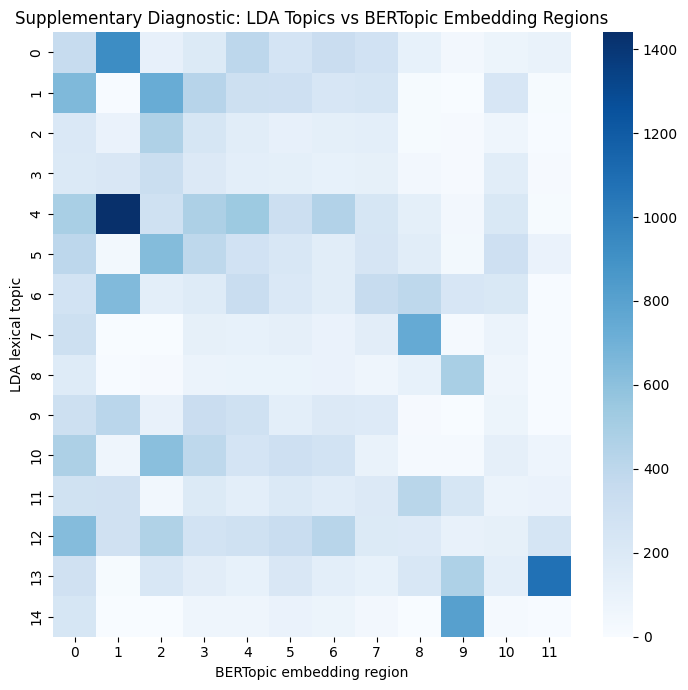

Saved: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/lit_lda_bertopic_contingency.png
Section 12 complete.


In [45]:
print('='*85)
print('SECTION 12: LITERATURE EMBEDDING TOPIC REGIONS (BERTOPIC)')
print('='*85)

from collections import Counter
import math
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import MiniBatchKMeans

LIT_BERTOPIC_MODEL_FILE = EMBEDDINGS_DIR / 'literature' / 'lit_bertopic_model.pkl'
LIT_BERTOPIC_ASSIGNMENTS_FILE = PREPARED_DIR / 'lit_bertopic_assignments.csv'
LIT_BERTOPIC_TOPIC_INFO_FILE = PREPARED_DIR / 'lit_bertopic_topic_info.csv'
LIT_LDA_BERTOPIC_AGREEMENT_FILE = TABLES_DIR / 'lit_lda_bertopic_agreement.csv'
LIT_LDA_BERTOPIC_CONTINGENCY_FIG = RESULTS_DIR / 'figures' / condition / 'lit_lda_bertopic_contingency.png'
LIT_LDA_BERTOPIC_CONTINGENCY_TABLE = TABLES_DIR / 'lit_lda_bertopic_contingency.csv'

# Fixed-granularity BERTopic: use BioLinkBERT embeddings + UMAP + MiniBatchKMeans + c-TF-IDF.
# HDBSCAN found only two broad density masses in this corpus; KMeans gives readable 10-15 map regions.
BERTOPIC_CLUSTERING_MODE = 'minibatch_kmeans'
BERTOPIC_N_REGIONS = 12
BERTOPIC_MIN_ACCEPTABLE_REGIONS = 10
BERTOPIC_MAX_ACCEPTABLE_REGIONS = 15
BERTOPIC_LABEL_STRATEGY = 'contrastive_phrase_v4'
BERTOPIC_LABEL_CANDIDATES = 50
BERTOPIC_LABEL_TERMS = 4
BERTOPIC_CONTRASTIVE_MAX_FEATURES = 50000
BERTOPIC_CONTRASTIVE_MIN_DF = 8
BERTOPIC_CONTRASTIVE_MAX_DF = 0.60

# These single-word terms are too broad to distinguish nearby biomedical regions on the UMAP.
# Multi-word phrases containing them are still allowed when the full phrase is region-specific.
BERTOPIC_LABEL_GENERIC_SINGLETONS = {
    'cell', 'cells', 'cancer', 'cancers', 'emerging', 'emergence', 'study', 'studies',
    'review', 'reviews', 'role', 'roles', 'expression', 'expressions', 'patient', 'patients',
    'research', 'result', 'results', 'protein', 'proteins', 'gene', 'genes', 'using', 'based',
    'analysis', 'data', 'disease', 'diseases', 'human', 'humans', 'model', 'models',
    'potential', 'potentials',
}

for _p in [LIT_BERTOPIC_MODEL_FILE.parent, LIT_BERTOPIC_ASSIGNMENTS_FILE.parent, LIT_LDA_BERTOPIC_AGREEMENT_FILE.parent, LIT_LDA_BERTOPIC_CONTINGENCY_FIG.parent]:
    _p.mkdir(parents=True, exist_ok=True)


def _literature_texts_for_labels(articles):
    texts = []
    for art in articles:
        title = str(art.get('title', '') or '').strip()
        abstract = str(art.get('abstract', '') or '').strip()
        texts.append(f'{title}. {abstract}'.strip())
    return texts


def _canonical_label_term(term):
    tokens = re.findall(r'[a-z0-9]+', str(term).lower())
    canon_tokens = []
    for tok in tokens:
        if len(tok) > 4 and tok.endswith('s'):
            tok = tok[:-1]
        canon_tokens.append(tok)
    return ' '.join(canon_tokens)


def _term_tokens(term):
    return re.findall(r'[a-z0-9]+', str(term).lower())


def _is_label_candidate(term):
    term = str(term).strip().lower()
    if not term or len(term) < 3:
        return False
    tokens = _term_tokens(term)
    if not tokens:
        return False
    canon = _canonical_label_term(term)
    # Exclude only exact/generic singleton labels; keep phrases such as "therapeutic potential".
    if len(tokens) == 1 and (tokens[0] in BERTOPIC_LABEL_GENERIC_SINGLETONS or canon in BERTOPIC_LABEL_GENERIC_SINGLETONS):
        return False
    if all(tok in BERTOPIC_LABEL_GENERIC_SINGLETONS for tok in tokens):
        return False
    if sum(ch.isalpha() for ch in term) < 3:
        return False
    return True


def _topic_terms_with_scores(topic_model, topic_info_df, tid, n=BERTOPIC_LABEL_CANDIDATES):
    terms = []
    if topic_model is not None and int(tid) != -1:
        try:
            terms = topic_model.get_topic(int(tid)) or []
        except Exception:
            terms = []
    if terms:
        out = []
        for rank, item in enumerate(terms[:n]):
            if not item:
                continue
            term = str(item[0]).strip()
            score = float(item[1]) if len(item) > 1 and item[1] is not None else 0.0
            out.append((term, score, rank))
        return out

    if topic_info_df is not None and 'Topic' in topic_info_df.columns:
        row = topic_info_df.loc[topic_info_df['Topic'].astype(int) == int(tid)]
        if len(row):
            for col in ['top_terms', 'Representation', 'Name']:
                if col in row.columns:
                    val = row.iloc[0][col]
                    if isinstance(val, str) and val.strip():
                        val = val.strip().strip('[]')
                        parts = [p.strip().strip("'\"") for p in re.split(r';|,', val) if p.strip()]
                        return [(term, 0.0, rank) for rank, term in enumerate(parts[:n])]
    return []


def _raw_ctfidf_term_maps(topic_model, topic_info_df, topic_ids):
    topic_terms_map = {-1: []}
    raw_label_map = {-1: 'unassigned embedding outlier'}
    for tid in topic_ids:
        tid = int(tid)
        if tid == -1:
            continue
        raw_terms = _topic_terms_with_scores(topic_model, topic_info_df, tid)
        terms = [term for term, _, _ in raw_terms]
        topic_terms_map[tid] = terms
        raw_label_map[tid] = ', '.join(terms[:BERTOPIC_LABEL_TERMS]) if terms else f'Topic {tid}'
    return topic_terms_map, raw_label_map


def _phrase_bonus(term):
    n = len(_term_tokens(term))
    if n >= 3:
        return 1.45
    if n == 2:
        return 1.30
    return 0.72


def _token_overlap(a, b):
    ta = set(_term_tokens(a))
    tb = set(_term_tokens(b))
    if not ta or not tb:
        return 0.0
    return len(ta & tb) / len(ta | tb)


def _contrastive_phrase_labels(lit_texts, bertopic_topics, topic_ids, n_label_terms=BERTOPIC_LABEL_TERMS):
    assigned = np.asarray(bertopic_topics, dtype=int)
    topic_ids = [int(t) for t in topic_ids if int(t) != -1]
    label_map = {-1: 'unassigned embedding outlier'}
    contrastive_terms_map = {-1: []}
    if not topic_ids:
        return label_map, contrastive_terms_map

    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=(1, 3),
        min_df=BERTOPIC_CONTRASTIVE_MIN_DF,
        max_df=BERTOPIC_CONTRASTIVE_MAX_DF,
        max_features=BERTOPIC_CONTRASTIVE_MAX_FEATURES,
    )
    X = vectorizer.fit_transform(lit_texts)
    terms = np.asarray(vectorizer.get_feature_names_out())
    X_bin = X.copy()
    X_bin.data = np.ones_like(X_bin.data)

    total_tf = np.asarray(X.sum(axis=0)).ravel().astype(float)
    total_df = np.asarray(X_bin.sum(axis=0)).ravel().astype(float)
    total_tokens = float(total_tf.sum())
    n_docs = X.shape[0]
    vocab_size = max(1, X.shape[1])

    topic_stats = {}
    term_region_presence = np.zeros(vocab_size, dtype=int)
    for tid in topic_ids:
        mask = assigned == tid
        n_region = int(mask.sum())
        if n_region == 0:
            continue
        region_tf = np.asarray(X[mask].sum(axis=0)).ravel().astype(float)
        region_df = np.asarray(X_bin[mask].sum(axis=0)).ravel().astype(float)
        min_region_docs = max(3, min(25, int(math.ceil(n_region * 0.002))))
        term_region_presence += (region_df >= min_region_docs).astype(int)
        topic_stats[tid] = {
            'mask': mask,
            'n_region': n_region,
            'region_tf': region_tf,
            'region_df': region_df,
            'region_tokens': float(region_tf.sum()),
            'min_region_docs': min_region_docs,
        }

    scored_by_topic = {}
    for tid, stats in topic_stats.items():
        n_region = stats['n_region']
        n_rest = max(1, n_docs - n_region)
        region_tf = stats['region_tf']
        region_df = stats['region_df']
        region_tokens = max(1.0, stats['region_tokens'])
        rest_tf = total_tf - region_tf
        rest_df = total_df - region_df
        rest_tokens = max(1.0, total_tokens - region_tokens)

        log_odds = np.log((region_tf + 0.5) / (region_tokens + 0.5 * vocab_size)) - np.log((rest_tf + 0.5) / (rest_tokens + 0.5 * vocab_size))
        prevalence_lift = np.log((region_df + 1.0) / (n_region + 2.0)) - np.log((rest_df + 1.0) / (n_rest + 2.0))
        support = np.log1p(region_df)
        base_score = (log_odds + 0.65 * prevalence_lift) * support

        candidates = []
        min_docs = stats['min_region_docs']
        candidate_idx = np.where((region_df >= min_docs) & (base_score > 0))[0]
        for j in candidate_idx:
            term = str(terms[j])
            if not _is_label_candidate(term):
                continue
            overlap_penalty = 1.0 / math.sqrt(max(1, int(term_region_presence[j])))
            phrase_score = float(base_score[j]) * _phrase_bonus(term) * overlap_penalty
            candidates.append({
                'term': term,
                'canon': _canonical_label_term(term),
                'score': phrase_score,
                'region_df': int(region_df[j]),
                'rest_df': int(rest_df[j]),
                'topic_df': int(term_region_presence[j]),
                'n_tokens': len(_term_tokens(term)),
            })
        candidates.sort(key=lambda d: (-d['score'], -d['n_tokens'], d['topic_df'], d['term']))
        scored_by_topic[tid] = candidates

    used_canons = set()
    topic_order = sorted(topic_ids, key=lambda t: topic_stats.get(t, {}).get('n_region', 0), reverse=True)
    for tid in topic_order:
        candidates = scored_by_topic.get(tid, [])
        selected = []
        selected_canons = set()

        # First pass: prefer distinctive phrases. Second pass: allow specific singletons if needed.
        for min_tokens in [2, 1]:
            while len(selected) < n_label_terms:
                best = None
                best_mmr = None
                for cand in candidates:
                    if cand['n_tokens'] < min_tokens:
                        continue
                    if cand['canon'] in selected_canons or cand['canon'] in used_canons:
                        continue
                    redundancy = max([_token_overlap(cand['term'], s) for s in selected], default=0.0)
                    mmr_score = cand['score'] - 0.85 * redundancy * cand['score']
                    if best is None or mmr_score > best_mmr:
                        best = cand
                        best_mmr = mmr_score
                if best is None:
                    break
                selected.append(best['term'])
                selected_canons.add(best['canon'])
            if len(selected) >= max(2, min(n_label_terms, 3)):
                break

        if not selected:
            # Use the highest scoring candidates even if another region already claimed a related phrase.
            for cand in candidates:
                if cand['canon'] in selected_canons:
                    continue
                selected.append(cand['term'])
                selected_canons.add(cand['canon'])
                if len(selected) >= n_label_terms:
                    break

        label_map[tid] = ', '.join(selected[:n_label_terms]) if selected else f'Region {tid}'
        contrastive_terms_map[tid] = selected[:n_label_terms]
        used_canons.update(selected_canons)

    return label_map, contrastive_terms_map


def _apply_contrastive_bertopic_labels(lit_texts, lit_bertopic_df, topic_info_df, topic_model=None):
    topic_ids = sorted(int(t) for t in pd.Series(lit_bertopic_df['bertopic_topic']).dropna().unique())
    topic_terms_map, raw_label_map = _raw_ctfidf_term_maps(topic_model, topic_info_df, topic_ids)
    contrastive_label_map, contrastive_terms_map = _contrastive_phrase_labels(
        lit_texts,
        lit_bertopic_df['bertopic_topic'].to_numpy(dtype=int),
        topic_ids,
    )

    topic_info_df = topic_info_df.copy()
    topic_info_df['top_terms'] = topic_info_df['Topic'].map(lambda t: '; '.join(topic_terms_map.get(int(t), [])))
    topic_info_df['contrastive_terms'] = topic_info_df['Topic'].map(lambda t: '; '.join(contrastive_terms_map.get(int(t), [])))
    topic_info_df['display_label_raw_ctfidf'] = topic_info_df['Topic'].map(lambda t: raw_label_map.get(int(t), f'Topic {t}'))
    topic_info_df['display_label'] = topic_info_df['Topic'].map(lambda t: contrastive_label_map.get(int(t), f'Topic {t}'))
    topic_info_df['display_label_strategy'] = BERTOPIC_LABEL_STRATEGY
    topic_info_df['bertopic_cluster_model'] = BERTOPIC_CLUSTERING_MODE
    topic_info_df['bertopic_target_regions'] = BERTOPIC_N_REGIONS

    lit_bertopic_df = lit_bertopic_df.copy()
    lit_bertopic_df['bertopic_label'] = [contrastive_label_map.get(int(t), f'Topic {t}') for t in lit_bertopic_df['bertopic_topic']]
    lit_bertopic_df['bertopic_top_terms'] = ['; '.join(topic_terms_map.get(int(t), [])) for t in lit_bertopic_df['bertopic_topic']]
    lit_bertopic_df['bertopic_contrastive_terms'] = ['; '.join(contrastive_terms_map.get(int(t), [])) for t in lit_bertopic_df['bertopic_topic']]
    lit_bertopic_df['bertopic_label_strategy'] = BERTOPIC_LABEL_STRATEGY

    return lit_bertopic_df, topic_info_df


lit_texts_bt = _literature_texts_for_labels(articles)
lit_bertopic_df = None
lit_bertopic_topic_info_df = None
use_cached_bt = False
if LIT_BERTOPIC_MODEL_FILE.exists() and LIT_BERTOPIC_ASSIGNMENTS_FILE.exists() and LIT_BERTOPIC_TOPIC_INFO_FILE.exists():
    cached_bt_df = pd.read_csv(LIT_BERTOPIC_ASSIGNMENTS_FILE)
    cached_bt_info_df = pd.read_csv(LIT_BERTOPIC_TOPIC_INFO_FILE)
    cached_regions = len([t for t in cached_bt_df['bertopic_topic'].unique() if int(t) >= 0])
    cached_mode = str(cached_bt_df.get('bertopic_cluster_model', pd.Series(['unknown'])).iloc[0])
    if (BERTOPIC_MIN_ACCEPTABLE_REGIONS <= cached_regions <= BERTOPIC_MAX_ACCEPTABLE_REGIONS
            and cached_mode == BERTOPIC_CLUSTERING_MODE):
        print(f'Loading cached BERTopic assignments: {LIT_BERTOPIC_ASSIGNMENTS_FILE}')
        lit_bertopic_df = cached_bt_df
        lit_bertopic_topic_info_df = cached_bt_info_df
        use_cached_bt = True
        print(f'Loaded {len(lit_bertopic_df)} literature-region assignments ({cached_regions} regions)')

        cached_label_strategy = str(cached_bt_info_df.get('display_label_strategy', pd.Series(['unknown'])).iloc[0])
        if cached_label_strategy != BERTOPIC_LABEL_STRATEGY:
            print(f'Refreshing cached BERTopic display labels with {BERTOPIC_LABEL_STRATEGY} (no BERTopic refit).')
            topic_model_cached = None
            if LIT_BERTOPIC_MODEL_FILE.exists():
                try:
                    topic_model_cached = load_pickle(LIT_BERTOPIC_MODEL_FILE)
                except Exception as exc:
                    print(f'WARNING: Could not load cached BERTopic model for raw c-TF-IDF terms: {exc}')
            topic_info_cached = topic_model_cached.get_topic_info().copy() if topic_model_cached is not None else cached_bt_info_df
            lit_bertopic_df, lit_bertopic_topic_info_df = _apply_contrastive_bertopic_labels(
                lit_texts_bt,
                lit_bertopic_df,
                topic_info_cached,
                topic_model=topic_model_cached,
            )
            lit_bertopic_df.to_csv(LIT_BERTOPIC_ASSIGNMENTS_FILE, index=False)
            lit_bertopic_topic_info_df.to_csv(LIT_BERTOPIC_TOPIC_INFO_FILE, index=False)
            print(f'Resaved contrastive phrase labels: {LIT_BERTOPIC_TOPIC_INFO_FILE}')
    else:
        print('Cached BERTopic artifacts do not match current fixed-granularity configuration; recomputing.')
        print(f'  cached regions={cached_regions}, cached mode={cached_mode}')
        print(f'  target mode={BERTOPIC_CLUSTERING_MODE}, target regions={BERTOPIC_N_REGIONS}')

if not use_cached_bt:
    try:
        from bertopic import BERTopic
        import umap as umap_lib
    except ImportError as exc:
        print('WARNING: BERTopic/UMAP dependencies are not installed; skipping Section 12.')
        print('Install dependencies before running this section: pip install bertopic umap-learn')
        print(f'Import error: {exc}')
        lit_bertopic_df = None
        lit_bertopic_topic_info_df = None
    else:
        X_lit_bt = np.asarray(lit_payload['embeddings'], dtype=np.float32)
        X_lit_bt = X_lit_bt / np.clip(np.linalg.norm(X_lit_bt, axis=1, keepdims=True), 1e-12, None)

        print(
            f'Fitting BERTopic on {len(lit_texts_bt):,} literature documents using precomputed BioLinkBERT embeddings '
            f'and {BERTOPIC_N_REGIONS} MiniBatchKMeans regions...'
        )
        umap_model_bt = umap_lib.UMAP(
            n_neighbors=30,
            n_components=5,
            min_dist=0.0,
            metric='cosine',
            random_state=42,
            low_memory=True,
        )
        cluster_model_bt = MiniBatchKMeans(
            n_clusters=BERTOPIC_N_REGIONS,
            random_state=42,
            batch_size=2048,
            n_init=20,
            reassignment_ratio=0.01,
        )
        # BERTopic applies this vectorizer to topic-level aggregate documents for c-TF-IDF.
        # Keep df thresholds permissive so small/strict cluster solutions do not fail.
        vectorizer_model_bt = CountVectorizer(
            stop_words='english',
            ngram_range=(1, 2),
            min_df=1,
            max_df=1.0,
            max_features=10000,
        )
        topic_model_bt = BERTopic(
            embedding_model=None,
            umap_model=umap_model_bt,
            hdbscan_model=cluster_model_bt,
            vectorizer_model=vectorizer_model_bt,
            calculate_probabilities=False,
            verbose=True,
        )
        bertopic_topics, bertopic_probs = topic_model_bt.fit_transform(lit_texts_bt, X_lit_bt)
        bertopic_topics = np.asarray(bertopic_topics, dtype=int)
        if bertopic_probs is None:
            bertopic_prob_arr = np.full(len(bertopic_topics), np.nan, dtype=float)
        else:
            bertopic_probs = np.asarray(bertopic_probs)
            bertopic_prob_arr = bertopic_probs.max(axis=1) if bertopic_probs.ndim == 2 else bertopic_probs.astype(float)

        lit_bertopic_df = pd.DataFrame({
            'article_idx': np.arange(len(articles)),
            'pmid': [art.get('pmid', '') for art in articles],
            'bertopic_topic': bertopic_topics,
            'bertopic_is_outlier': bertopic_topics == -1,
            'bertopic_prob': bertopic_prob_arr,
            'bertopic_cluster_model': BERTOPIC_CLUSTERING_MODE,
            'bertopic_target_regions': BERTOPIC_N_REGIONS,
        })
        topic_info_df = topic_model_bt.get_topic_info().copy()
        lit_bertopic_df, topic_info_df = _apply_contrastive_bertopic_labels(
            lit_texts_bt,
            lit_bertopic_df,
            topic_info_df,
            topic_model=topic_model_bt,
        )

        topic_info_df.to_csv(LIT_BERTOPIC_TOPIC_INFO_FILE, index=False)
        lit_bertopic_df.to_csv(LIT_BERTOPIC_ASSIGNMENTS_FILE, index=False)
        save_pickle(topic_model_bt, LIT_BERTOPIC_MODEL_FILE)
        lit_bertopic_topic_info_df = topic_info_df
        print(f'Saved: {LIT_BERTOPIC_MODEL_FILE}')
        print(f'Saved: {LIT_BERTOPIC_ASSIGNMENTS_FILE}')
        print(f'Saved: {LIT_BERTOPIC_TOPIC_INFO_FILE}')

if lit_bertopic_df is not None:
    assigned = lit_bertopic_df['bertopic_topic'].to_numpy()
    n_topics_bt = len([t for t in np.unique(assigned) if t >= 0])
    outlier_frac_bt = float((assigned == -1).mean())
    print(f'BERTopic regions: {n_topics_bt} non-outlier topics; outlier fraction={outlier_frac_bt:.1%}')
    print('Top BERTopic regions by article count:')
    print(lit_bertopic_df['bertopic_topic'].value_counts().head(15).to_string())

    if lit_bertopic_topic_info_df is not None and 'display_label' in lit_bertopic_topic_info_df.columns:
        preview_cols = ['Topic', 'Count', 'display_label']
        if 'display_label_raw_ctfidf' in lit_bertopic_topic_info_df.columns:
            preview_cols.append('display_label_raw_ctfidf')
        if 'contrastive_terms' in lit_bertopic_topic_info_df.columns:
            preview_cols.append('contrastive_terms')
        label_preview = (
            lit_bertopic_topic_info_df.loc[lit_bertopic_topic_info_df['Topic'].astype(int) >= 0, preview_cols]
            .rename(columns={'Topic': 'bertopic_topic', 'Count': 'n_articles'})
            .sort_values('bertopic_topic')
        )
        print('\nContrastive BERTopic display labels for UMAP annotations:')
        display(label_preview)

    # Lexical-vs-embedding agreement diagnostic. Low agreement supports reporting them as complementary views.
    if LIT_TOPIC_ASSIGNMENTS_FILE.exists():
        lit_topic_for_agree = pd.read_csv(LIT_TOPIC_ASSIGNMENTS_FILE)
        if len(lit_topic_for_agree) == len(lit_bertopic_df):
            valid_agree = (lit_topic_for_agree['dominant_topic'].to_numpy() >= 0) & (assigned >= 0)
            if valid_agree.sum() > 1:
                ari_bt_lda = adjusted_rand_score(lit_topic_for_agree.loc[valid_agree, 'dominant_topic'], assigned[valid_agree])
                nmi_bt_lda = normalized_mutual_info_score(lit_topic_for_agree.loc[valid_agree, 'dominant_topic'], assigned[valid_agree])
                agreement_df = pd.DataFrame([{
                    'n_articles_compared': int(valid_agree.sum()),
                    'lda_topics': int(lit_topic_for_agree.loc[valid_agree, 'dominant_topic'].nunique()),
                    'bertopic_regions': int(pd.Series(assigned[valid_agree]).nunique()),
                    'ari_lda_vs_bertopic': float(ari_bt_lda),
                    'nmi_lda_vs_bertopic': float(nmi_bt_lda),
                    'interpretation': 'low agreement means lexical LDA and embedding regions are complementary',
                }])
                agreement_df.to_csv(LIT_LDA_BERTOPIC_AGREEMENT_FILE, index=False)
                print('\nLDA vs BERTopic agreement:')
                print(agreement_df.to_string(index=False))

                contingency_bt = pd.crosstab(
                    lit_topic_for_agree.loc[valid_agree, 'dominant_topic'],
                    assigned[valid_agree],
                    rownames=['lda_topic'],
                    colnames=['bertopic_region'],
                )
                contingency_bt.to_csv(LIT_LDA_BERTOPIC_CONTINGENCY_TABLE)
                if contingency_bt.shape[0] > 0 and contingency_bt.shape[1] > 0:
                    import matplotlib.pyplot as plt
                    import seaborn as sns
                    fig, ax = plt.subplots(figsize=(min(18, 3 + 0.35 * contingency_bt.shape[1]), 7))
                    sns.heatmap(contingency_bt, cmap='Blues', ax=ax)
                    ax.set_title('Supplementary Diagnostic: LDA Topics vs BERTopic Embedding Regions')
                    ax.set_xlabel('BERTopic embedding region')
                    ax.set_ylabel('LDA lexical topic')
                    plt.tight_layout()
                    fig.savefig(LIT_LDA_BERTOPIC_CONTINGENCY_FIG, dpi=200, bbox_inches='tight')
                    plt.show()
                    print(f'Saved: {LIT_LDA_BERTOPIC_CONTINGENCY_FIG}')
        else:
            print('WARNING: LDA assignment count does not match BERTopic assignment count; skipping agreement diagnostic.')

print('Section 12 complete.')


## 13. Literature-Space UMAP (Literature Only) [UPDATE]

[UPDATE] The 2D UMAP is a fixed visualization map fitted on literature embeddings only. BERTopic labels from Section 12 provide the primary region colors/labels on this map.

[UPDATE] This prepare-data section does not project proposals. Proposal projection into the saved literature UMAP reducer is handled only in `compare_proposals_rephrased.ipynb`.

[UPDATE] The diagnostic visualization added here is literature-only: it colors literature articles by BERTopic region and annotates those topic-region labels.


In [46]:
print('='*85)
print('SECTION 13: LITERATURE-SPACE UMAP (LITERATURE ONLY)')
print('='*85)
print('NOTE: Fitting UMAP on 39k x 1024d is expensive (10-30 min on CPU). Skip-if-exists logic active.')
print('This prepare-data section fits/caches the literature map only. Proposal projection happens in compare_proposals_rephrased.ipynb.')

import umap as umap_lib

LIT_UMAP_REDUCER_FILE = EMBEDDINGS_DIR / 'literature' / 'lit_umap_reducer.pkl'
LIT_UMAP2D_FILE = EMBEDDINGS_DIR / 'literature' / 'lit_umap2d.npy'

X_lit_s12 = np.asarray(lit_payload['embeddings'], dtype=np.float32)
X_lit_s12 = X_lit_s12 / np.clip(np.linalg.norm(X_lit_s12, axis=1, keepdims=True), 1e-12, None)

print(f'X_lit: {X_lit_s12.shape}')

if LIT_UMAP_REDUCER_FILE.exists() and LIT_UMAP2D_FILE.exists():
    print(f'\nLoading cached literature UMAP: {LIT_UMAP2D_FILE}')
    lit_reducer = load_pickle(LIT_UMAP_REDUCER_FILE)
    lit_umap2d_s12 = np.load(LIT_UMAP2D_FILE)
    print(f'Loaded: {lit_umap2d_s12.shape}')
else:
    if LIT_UMAP2D_FILE.exists() and not LIT_UMAP_REDUCER_FILE.exists():
        print(f'\nPartial literature UMAP cache found: {LIT_UMAP2D_FILE} exists but reducer is missing.')
        print('Refitting UMAP so both lit_umap_reducer.pkl and lit_umap2d.npy are synchronized.')
    elif LIT_UMAP_REDUCER_FILE.exists() and not LIT_UMAP2D_FILE.exists():
        print(f'\nPartial literature UMAP cache found: reducer exists but {LIT_UMAP2D_FILE} is missing.')
        print('Refitting UMAP so both lit_umap_reducer.pkl and lit_umap2d.npy are synchronized.')
    else:
        print(f'\nFitting UMAP on {X_lit_s12.shape[0]:,} literature embeddings...')
    lit_reducer = umap_lib.UMAP(
        n_neighbors=20, min_dist=0.1, n_components=2,
        metric='cosine', random_state=42, low_memory=True
    )
    lit_umap2d_s12 = lit_reducer.fit_transform(X_lit_s12)
    save_pickle(lit_reducer, LIT_UMAP_REDUCER_FILE)
    np.save(LIT_UMAP2D_FILE, lit_umap2d_s12)
    print(f'Saved: {LIT_UMAP_REDUCER_FILE}')
    print(f'Saved: {LIT_UMAP2D_FILE}')

print(f'\nLit UMAP 2D: {lit_umap2d_s12.shape}')
print('No proposal embeddings were loaded, projected, or saved in this prepare-data section.')


SECTION 13: LITERATURE-SPACE UMAP (LITERATURE ONLY)
NOTE: Fitting UMAP on 39k x 1024d is expensive (10-30 min on CPU). Skip-if-exists logic active.
This prepare-data section fits/caches the literature map only. Proposal projection happens in compare_proposals_rephrased.ipynb.
X_lit: (39538, 1024)

Loading cached literature UMAP: /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/literature/lit_umap2d.npy
Loaded: (39538, 2)

Lit UMAP 2D: (39538, 2)
No proposal embeddings were loaded, projected, or saved in this prepare-data section.


SECTION 13B: LITERATURE UMAP COLORED BY BERTOPIC REGIONS


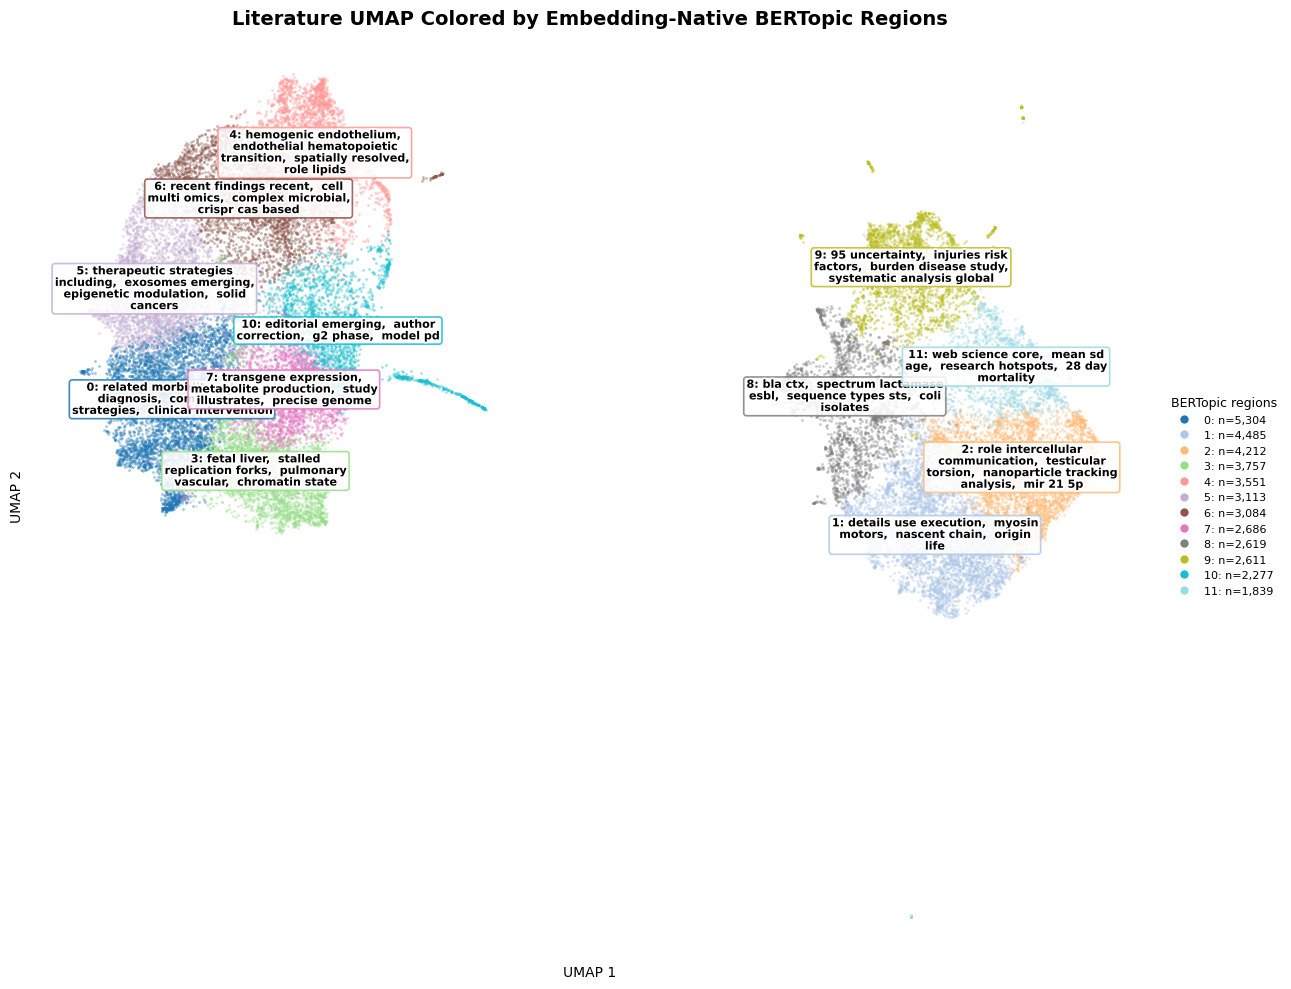

Saved literature-only BERTopic UMAP visualization: /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/figures/rephrased/minimal/literature_umap_bertopic_regions_prepare.png
BERTopic region labels shown on the map:


,bertopic_topic,n_articles,display_label
0,0,5304,"related morbidity, stage diagnosis, combinatio..."
1,1,4485,"details use execution, myosin motors, nascent ..."
2,2,4212,"role intercellular communication, testicular t..."
3,3,3757,"fetal liver, stalled replication forks, pulmon..."
4,4,3551,"hemogenic endothelium, endothelial hematopoiet..."
5,5,3113,"therapeutic strategies including, exosomes eme..."
6,6,3084,"recent findings recent, cell multi omics, comp..."
7,7,2686,"transgene expression, metabolite production, s..."
8,8,2619,"bla ctx, spectrum lactamase esbl, sequence typ..."
9,9,2611,"95 uncertainty, injuries risk factors, burden ..."


In [47]:
print('='*85)
print('SECTION 13B: LITERATURE UMAP COLORED BY BERTOPIC REGIONS')
print('='*85)

import textwrap
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.lines import Line2D
from IPython.display import display

LIT_BERTOPIC_UMAP_FIG = RESULTS_DIR / 'figures' / condition / 'literature_umap_bertopic_regions_prepare.png'
LIT_BERTOPIC_UMAP_FIG.parent.mkdir(parents=True, exist_ok=True)

required_region_plot_files = [
    LIT_UMAP2D_FILE,
    LIT_BERTOPIC_ASSIGNMENTS_FILE,
    LIT_BERTOPIC_TOPIC_INFO_FILE,
]
missing_region_plot_files = [p for p in required_region_plot_files if not p.exists()]

if missing_region_plot_files:
    print('Skipping literature-only BERTopic UMAP visualization; missing required files:')
    for p in missing_region_plot_files:
        print(f'  MISSING {p}')
    print('Run Section 12 and the main Section 13 projection cell first, then rerun this cell.')
else:
    lit_umap_vis = np.load(LIT_UMAP2D_FILE)
    lit_bt_vis = pd.read_csv(LIT_BERTOPIC_ASSIGNMENTS_FILE)
    lit_bt_info_vis = pd.read_csv(LIT_BERTOPIC_TOPIC_INFO_FILE)

    if 'article_idx' in lit_bt_vis.columns:
        lit_bt_vis = (
            lit_bt_vis.set_index('article_idx')
            .reindex(np.arange(len(lit_umap_vis)))
            .reset_index()
        )
    elif len(lit_bt_vis) != len(lit_umap_vis):
        raise ValueError(
            f'BERTopic assignment rows ({len(lit_bt_vis)}) do not match UMAP rows ({len(lit_umap_vis)}), '
            'and no article_idx column is available for alignment.'
        )

    topics_vis = pd.to_numeric(lit_bt_vis['bertopic_topic'], errors='coerce').fillna(-1).astype(int).to_numpy()
    valid_topics_vis = sorted(int(t) for t in np.unique(topics_vis) if int(t) >= 0)

    if not valid_topics_vis:
        print('No non-outlier BERTopic regions found to visualize.')
    else:
        label_map_vis = {}
        if 'Topic' in lit_bt_info_vis.columns:
            for _, row in lit_bt_info_vis.iterrows():
                try:
                    topic_id = int(row['Topic'])
                except Exception:
                    continue
                display_label = row.get('display_label', '')
                if pd.isna(display_label) or str(display_label).strip() == '':
                    display_label = row.get('Name', f'Topic {topic_id}')
                label_map_vis[topic_id] = str(display_label)

        if 'bertopic_label' in lit_bt_vis.columns:
            assignment_labels = (
                lit_bt_vis.loc[topics_vis >= 0, ['bertopic_topic', 'bertopic_label']]
                .dropna()
                .drop_duplicates(subset=['bertopic_topic'])
            )
            for _, row in assignment_labels.iterrows():
                label_map_vis.setdefault(int(row['bertopic_topic']), str(row['bertopic_label']))

        counts_vis = pd.Series(topics_vis).value_counts().sort_index()
        summary_rows_vis = []
        for topic_id in valid_topics_vis:
            summary_rows_vis.append({
                'bertopic_topic': topic_id,
                'n_articles': int(counts_vis.get(topic_id, 0)),
                'display_label': label_map_vis.get(topic_id, f'Topic {topic_id}'),
            })
        topic_summary_vis = pd.DataFrame(summary_rows_vis).sort_values('bertopic_topic')

        cmap_vis = plt.get_cmap('tab20', max(len(valid_topics_vis), 1))
        color_map_vis = {topic_id: cmap_vis(i % cmap_vis.N) for i, topic_id in enumerate(valid_topics_vis)}

        fig, ax = plt.subplots(figsize=(13, 10))

        outlier_mask_vis = topics_vis < 0
        if outlier_mask_vis.any():
            ax.scatter(
                lit_umap_vis[outlier_mask_vis, 0],
                lit_umap_vis[outlier_mask_vis, 1],
                s=3,
                c='#d9d9d9',
                alpha=0.18,
                linewidths=0,
                rasterized=True,
                label='Outlier / unassigned',
            )

        for topic_id in valid_topics_vis:
            mask = topics_vis == topic_id
            ax.scatter(
                lit_umap_vis[mask, 0],
                lit_umap_vis[mask, 1],
                s=4,
                c=[color_map_vis[topic_id]],
                alpha=0.42,
                linewidths=0,
                rasterized=True,
            )

        for topic_id in valid_topics_vis:
            mask = topics_vis == topic_id
            if not mask.any():
                continue
            centroid_x, centroid_y = np.median(lit_umap_vis[mask], axis=0)
            label = label_map_vis.get(topic_id, f'Topic {topic_id}')
            label = ', '.join(str(label).split(',')[:4]).strip()
            label_text = textwrap.fill(f'{topic_id}: {label}', width=34)
            txt = ax.text(
                centroid_x,
                centroid_y,
                label_text,
                fontsize=8,
                fontweight='bold',
                ha='center',
                va='center',
                color='black',
                bbox={
                    'boxstyle': 'round,pad=0.25',
                    'facecolor': 'white',
                    'edgecolor': color_map_vis[topic_id],
                    'linewidth': 1.2,
                    'alpha': 0.86,
                },
                zorder=5,
            )
            txt.set_path_effects([path_effects.withStroke(linewidth=2.5, foreground='white')])

        legend_handles_vis = [
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                markerfacecolor=color_map_vis[topic_id],
                markersize=7,
                label=f'{topic_id}: n={int(counts_vis.get(topic_id, 0)):,}',
            )
            for topic_id in valid_topics_vis
        ]
        ax.legend(
            handles=legend_handles_vis,
            title='BERTopic regions',
            loc='center left',
            bbox_to_anchor=(1.01, 0.5),
            frameon=False,
            fontsize=8,
            title_fontsize=9,
        )

        ax.set_title('Literature UMAP Colored by Embedding-Native BERTopic Regions', fontsize=14, fontweight='bold')
        ax.set_xlabel('UMAP 1')
        ax.set_ylabel('UMAP 2')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        fig.tight_layout()
        fig.savefig(LIT_BERTOPIC_UMAP_FIG, dpi=220, bbox_inches='tight')
        plt.show()

        print(f'Saved literature-only BERTopic UMAP visualization: {LIT_BERTOPIC_UMAP_FIG}')
        print('BERTopic region labels shown on the map:')
        display(topic_summary_vis)


## 14. Artifact Summary [UPDATE]


In [38]:
artifact_paths = [
    PREPARED_ALL_PROPOSALS_PATH,
    PREPARED_ALL_PROPOSALS_CSV,
    ALL_PROPOSALS_PATH,
    NCEMS_ALL_REVIEWS_PATH,
    NOVELTY_ALL_REVIEWS_PATH,
    REVIEW_SCORES_WIDE_PATH,
    PROPOSAL_FULL_EMBEDDINGS_FILE,
    PROPOSAL_ABSTRACT_EMBEDDINGS_FILE,
    LITERATURE_EMBEDDINGS_FILE,
    NCEMS_REVIEW_EMBEDDINGS_FILE,
    NOVELTY_REVIEW_EMBEDDINGS_FILE,
    EMBEDDINGS_DIR / 'literature' / 'lit_lda_model.pkl',
    PREPARED_DIR / 'lit_topic_assignments.csv',
    EMBEDDINGS_DIR / 'literature' / 'lit_bertopic_model.pkl',
    PREPARED_DIR / 'lit_bertopic_assignments.csv',
    PREPARED_DIR / 'lit_bertopic_topic_info.csv',
    EMBEDDINGS_DIR / 'literature' / 'lit_umap_reducer.pkl',
    EMBEDDINGS_DIR / 'literature' / 'lit_umap2d.npy',
    RESULTS_DIR / 'figures' / condition / 'literature_umap_bertopic_regions_prepare.png',
]

print('Prepared artifacts:')
for p in artifact_paths:
    exists = p.exists()
    size = p.stat().st_size / 1024 / 1024 if exists else 0
    print(f'  {"OK" if exists else "MISSING"} {p} ({size:.2f} MB)')

Prepared artifacts:
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.json (2.23 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/all_proposals.csv (0.61 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/results/tables/rephrased/minimal/all_proposals.json (2.23 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/ncems_criteria_all_reviews.csv (3.49 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/novelty_all_reviews.csv (0.35 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/prepared/rephrased/minimal/review_scores_wide.csv (0.04 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_human_ai_rephrased.pkl (0.53 MB)
  OK /Users/eveyhuang/Documents/NICO/human-AI-proposal/data/embeddings/rephrased/minimal/proposal_embeddings_section1_onl